# Explore here

In [18]:
# Step 0: Load Libraries
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)


In [2]:
#Step 1: Load data
url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"

df_raw = pd.read_csv(url)

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
#Step 2: Preprocessing

df_baking = df_raw.copy()
zero_as_nan_cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in zero_as_nan_cols:
    df_baking[col] = df_baking[col].replace(0, np.nan)


for col in zero_as_nan_cols:
    median_val = df_baking[col].median()
    df_baking[col].fillna(median_val, inplace=True)

df_baking.columns = df_baking.columns.str.lower()
df = df_baking.copy()
df.sample(10, random_state= 2025)

/tmp/ipykernel_8527/1463893122.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_baking[col].fillna(median_val, inplace=True)
/tmp/ipykernel_8527/1463893122.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
82,7,83.0,78.0,26.0,71.0,29.3,0.767,36,0
152,9,156.0,86.0,28.0,155.0,34.3,1.189,42,1
393,4,116.0,72.0,12.0,87.0,22.1,0.463,37,0
691,13,158.0,114.0,29.0,125.0,42.3,0.257,44,1
14,5,166.0,72.0,19.0,175.0,25.8,0.587,51,1
542,10,90.0,85.0,32.0,125.0,34.9,0.825,56,1
749,6,162.0,62.0,29.0,125.0,24.3,0.178,50,1
629,4,94.0,65.0,22.0,125.0,24.7,0.148,21,0
724,1,111.0,94.0,29.0,125.0,32.8,0.265,45,0
222,7,119.0,72.0,29.0,125.0,25.2,0.209,37,0


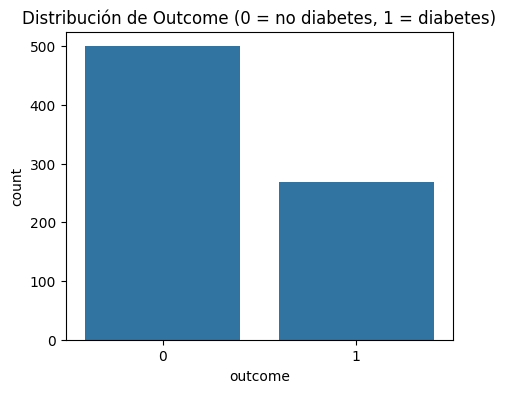

Proporción de clases:
 outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [7]:
#Step 3: EDA
# Distribución de la variable objetivo
plt.figure(figsize=(5,4))
sns.countplot(x='outcome', data=df)
plt.title("Distribución de Outcome (0 = no diabetes, 1 = diabetes)")
plt.show()

print("Proporción de clases:\n", df['outcome'].value_counts(normalize=True))

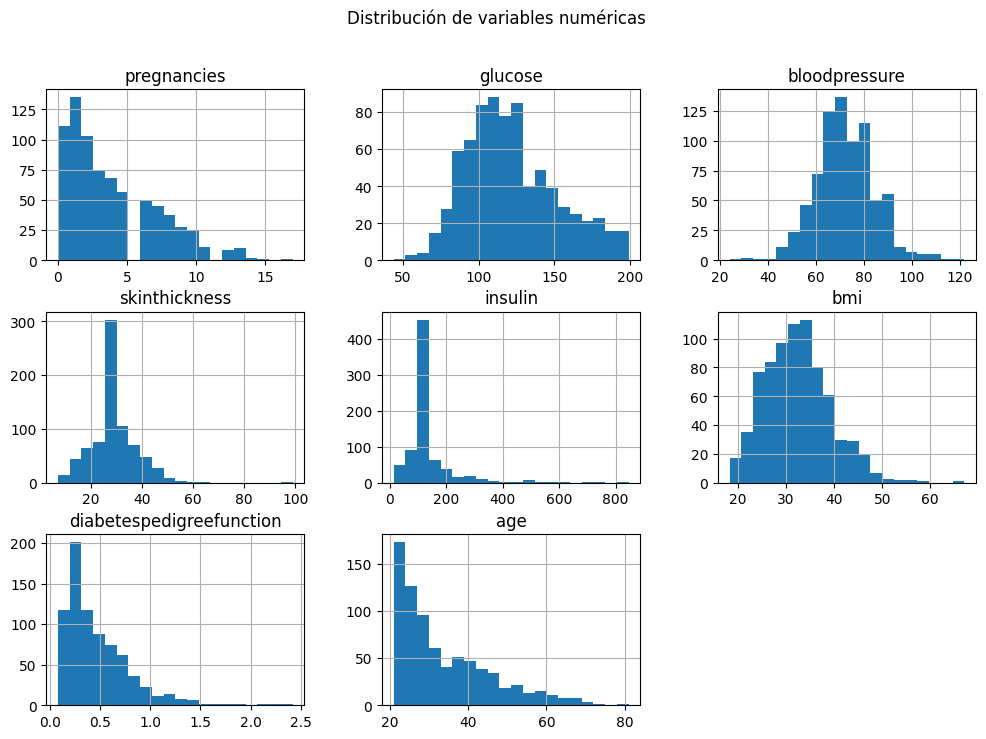

In [8]:
# Histogramas de variables numéricas
num_cols = [c for c in df.columns if c != 'outcome']
df[num_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Distribución de variables numéricas")
plt.show()

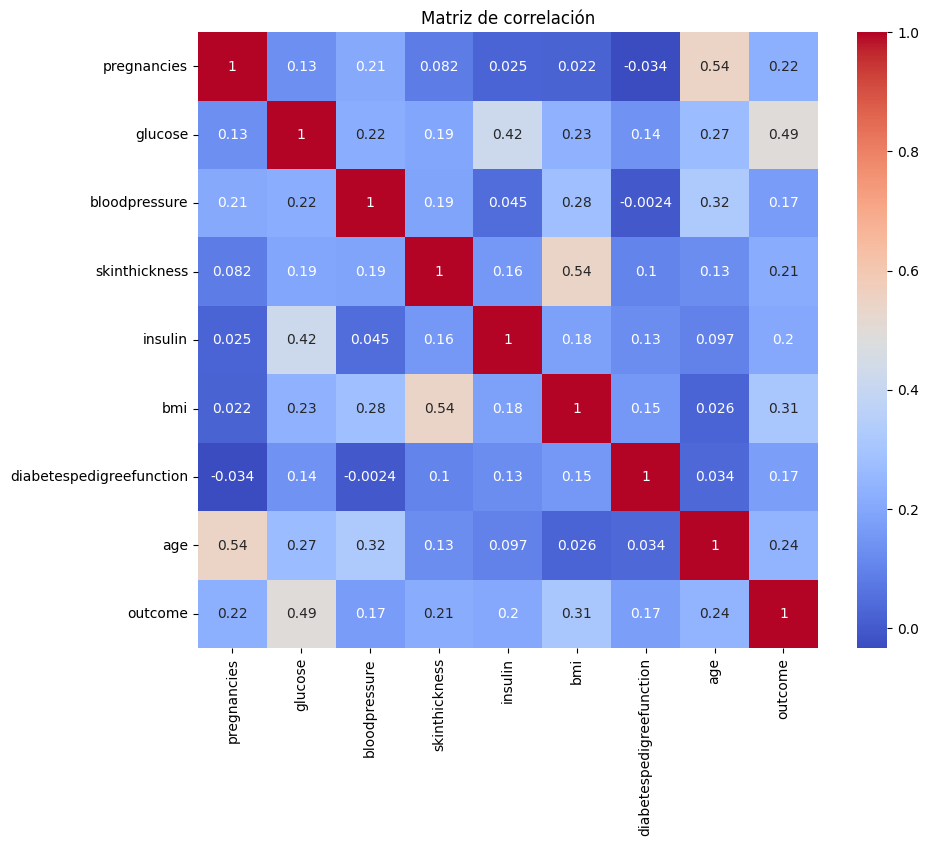

In [9]:
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

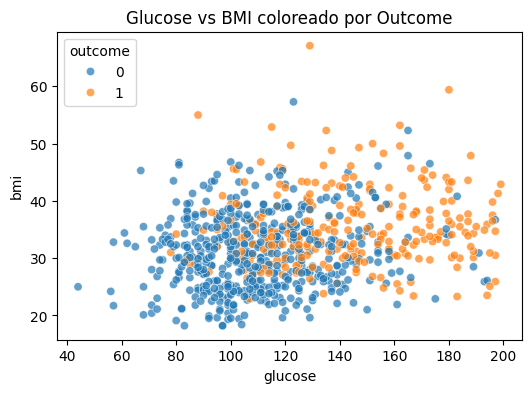

In [11]:
# Scatter simple de algunas variables con Outcome coloreado
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='glucose', y='bmi', hue='outcome', alpha=0.7)
plt.title("Glucose vs BMI coloreado por Outcome")
plt.show()

In [12]:
X = df.drop('outcome', axis=1)
y = df['outcome']

feature_names = X.columns.tolist()
print("Features:", feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shapes -> X_train:", X_train.shape, "| X_test:", X_test.shape)

Features: ['pregnancies', 'glucose', 'bloodpressure', 'skinthickness', 'insulin', 'bmi', 'diabetespedigreefunction', 'age']
Shapes -> X_train: (614, 8) | X_test: (154, 8)


In [13]:
#Step 5: ML
numeric_features = feature_names
numeric_transformer = 'passthrough'  # podría ser StandardScaler() si quisiéramos

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

criteria = ['gini', 'entropy', 'log_loss']  # funciones de pureza disponibles en sklearn

results_list = []

for crit in criteria:
    print(f"\nEntrenando árbol con criterion = '{crit}'")
    clf = DecisionTreeClassifier(
        criterion=crit,
        random_state=42
    )

    model_pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', clf)
        ]
    )

    model_pipeline.fit(X_train, y_train)

    y_train_pred = model_pipeline.predict(X_train)
    y_test_pred = model_pipeline.predict(X_test)
    y_test_proba = model_pipeline.predict_proba(X_test)[:, 1]

    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    roc = roc_auc_score(y_test, y_test_proba)

    print(f"Accuracy train: {acc_train:.4f}")
    print(f"Accuracy test : {acc_test:.4f}")
    print(f"Precision test: {prec:.4f}")
    print(f"Recall test   : {rec:.4f}")
    print(f"F1-score test : {f1:.4f}")
    print(f"ROC-AUC test  : {roc:.4f}")

    results_list.append({
        'criterion': crit,
        'acc_train': acc_train,
        'acc_test': acc_test,
        'precision_test': prec,
        'recall_test': rec,
        'f1_test': f1,
        'roc_auc_test': roc,
        'model': model_pipeline
    })

# Convertimos resultados a DataFrame para comparar
results_df = pd.DataFrame(results_list).drop(columns=['model'])
print("\nResumen de criterios:\n", results_df)


Entrenando árbol con criterion = 'gini'
Accuracy train: 1.0000
Accuracy test : 0.6818
Precision test: 0.5532
Recall test   : 0.4815
F1-score test : 0.5149
ROC-AUC test  : 0.6357

Entrenando árbol con criterion = 'entropy'
Accuracy train: 1.0000
Accuracy test : 0.6753
Precision test: 0.5385
Recall test   : 0.5185
F1-score test : 0.5283
ROC-AUC test  : 0.6393

Entrenando árbol con criterion = 'log_loss'
Accuracy train: 1.0000
Accuracy test : 0.6753
Precision test: 0.5385
Recall test   : 0.5185
F1-score test : 0.5283
ROC-AUC test  : 0.6393

Resumen de criterios:
   criterion  acc_train  acc_test  precision_test  recall_test   f1_test  \
0      gini        1.0  0.681818        0.553191     0.481481  0.514851   
1   entropy        1.0  0.675325        0.538462     0.518519  0.528302   
2  log_loss        1.0  0.675325        0.538462     0.518519  0.528302   

   roc_auc_test  
0      0.635741  
1      0.639259  
2      0.639259  


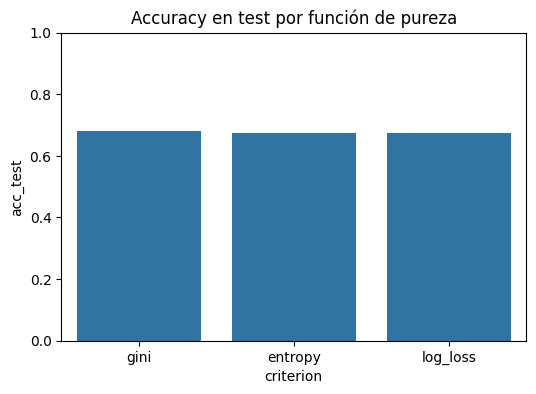

In [14]:
# Gráfico comparativo de accuracy test por criterio
plt.figure(figsize=(6,4))
sns.barplot(data=results_df, x='criterion', y='acc_test')
plt.title("Accuracy en test por función de pureza")
plt.ylim(0,1)
plt.show()

In [15]:
# Seleccionamos el mejor criterio según ROC-AUC en test
best_row = results_df.sort_values(by='roc_auc_test', ascending=False).iloc[0]
best_criterion = best_row['criterion']
print("\nMejor criterion según ROC-AUC test:", best_criterion)


Mejor criterion según ROC-AUC test: entropy


In [16]:
#Optimización del modelo
# Preprocesador para el grid (igual que antes)
preprocessor_opt = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

dt = DecisionTreeClassifier(
    criterion=best_criterion,
    random_state=42
)

pipe_dt = Pipeline(
    steps=[
        ('preprocessor', preprocessor_opt),
        ('classifier', dt)
    ]
)

param_grid = {
    'classifier__max_depth': [None, 3, 4, 5, 6, 8, 10],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4, 8],
    'classifier__max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    pipe_dt,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nMejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print("Mejor score ROC-AUC (cv):", grid_search.best_score_)

best_model = grid_search.best_estimator_


Mejores hiperparámetros encontrados:
{'classifier__max_depth': 3, 'classifier__max_features': None, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 2}
Mejor score ROC-AUC (cv): 0.8005841638981174



Métricas en TRAIN:
Accuracy : 0.760586319218241
Precision: 0.8383838383838383
Recall   : 0.3878504672897196
F1-score : 0.5303514376996805
ROC-AUC  : 0.8104147196261682

Métricas en TEST:
Accuracy : 0.6948051948051948
Precision: 0.6521739130434783
Recall   : 0.2777777777777778
F1-score : 0.38961038961038963
ROC-AUC  : 0.7704629629629629

Classification report (TEST):
              precision    recall  f1-score   support

           0       0.70      0.92      0.80       100
           1       0.65      0.28      0.39        54

    accuracy                           0.69       154
   macro avg       0.68      0.60      0.59       154
weighted avg       0.68      0.69      0.65       154



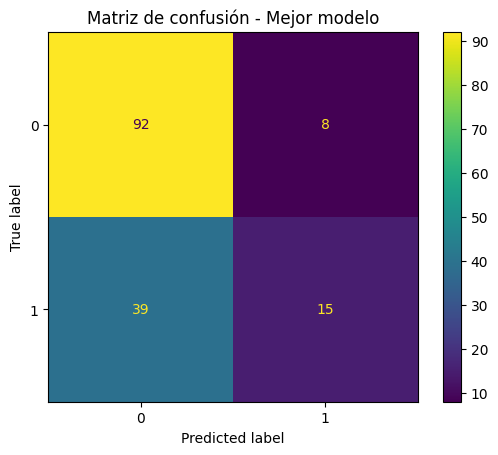

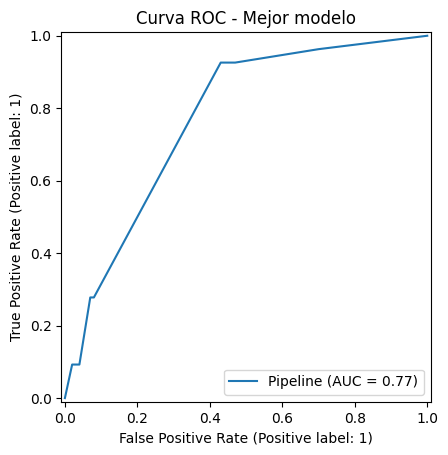

In [17]:
#Evaluación final 
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("\nMétricas en TRAIN:")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1-score :", f1_score(y_train, y_train_pred))
print("ROC-AUC  :", roc_auc_score(y_train, best_model.predict_proba(X_train)[:,1]))

print("\nMétricas en TEST:")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1-score :", f1_score(y_test, y_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_proba))

print("\nClassification report (TEST):")
print(classification_report(y_test, y_test_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(values_format='d')
plt.title("Matriz de confusión - Mejor modelo")
plt.show()

# Curva ROC
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Curva ROC - Mejor modelo")
plt.show()


In [19]:
models_dir = "models"
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, "diabetes_decision_tree_best.pkl")

with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

print(f"\nModelo guardado correctamente en: {model_path}")


Modelo guardado correctamente en: models/diabetes_decision_tree_best.pkl
